# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA & DLinear 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1. 시계열 데이터 분석에서는 정상성을 확보해야 구조를 안정적으로 분석할 수 있다. 정상성이 확보될 경우, 모델이 안정성있는 예측이 가능하며 회귀 분석에 유의미한 결론을 도출 할 수 있게된다.

ARIMA 모델은 시계열 데이터의 비정상성을 처리하기 위해서 Integrated 과정을 거친다. ARIMA 모델은 데이터의 차분을 통해서 추세를 제거하고 정상성을 가정하게 만든다.

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2. ACF가 천천히 감소하거나 PACF가 1시차 이후 감소한다는 것을 보아 비정상 시계열이고, 분산이 시간에 따라 변화하지 않는것을 보아 평균이나 추세 때문에 생기는 비정상성이라 예상할 수 있다. 1차 차분 이후 정상성을 확보 할 수 있는 것으로 예상된다. ACF가 절단, PACF가 점진적 감소임을 보아 MA 모델, ARIMA 모델로 설명 할 수 있다.

## 실습

- 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)입니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [6]:
# kaggle 데이터 로드
import os

path = "/content/"
print(os.listdir(path))

['.config', 'Summary_of_Weather.csv', 'Weather_Station_Locations.csv', 'sample_data']


In [7]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_df = pd.read_csv("/content/Weather_Station_Locations.csv")
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [8]:
# station별 실제 날씨 데이터
weather_df = pd.read_csv("/content/Summary_of_Weather.csv")

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 를 수치형 값(ex.0.1, 0.01)으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_1065/3179284165.py:2: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv("/content/Summary_of_Weather.csv")


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [9]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_1065/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_1065/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


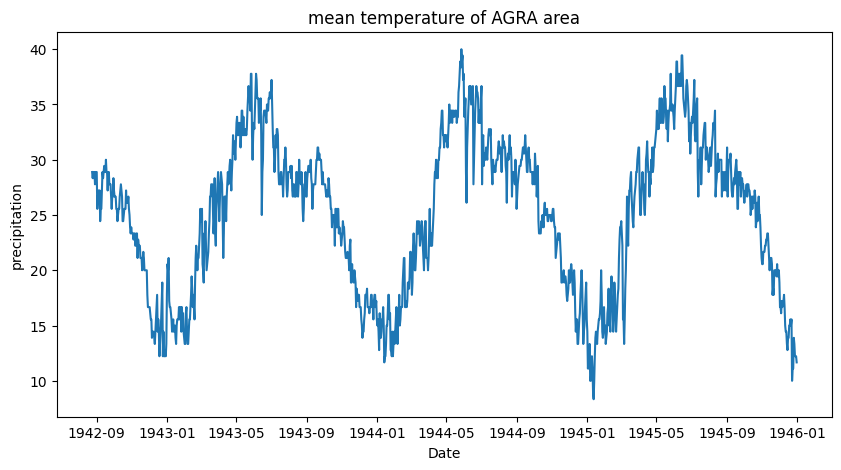

In [10]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [11]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

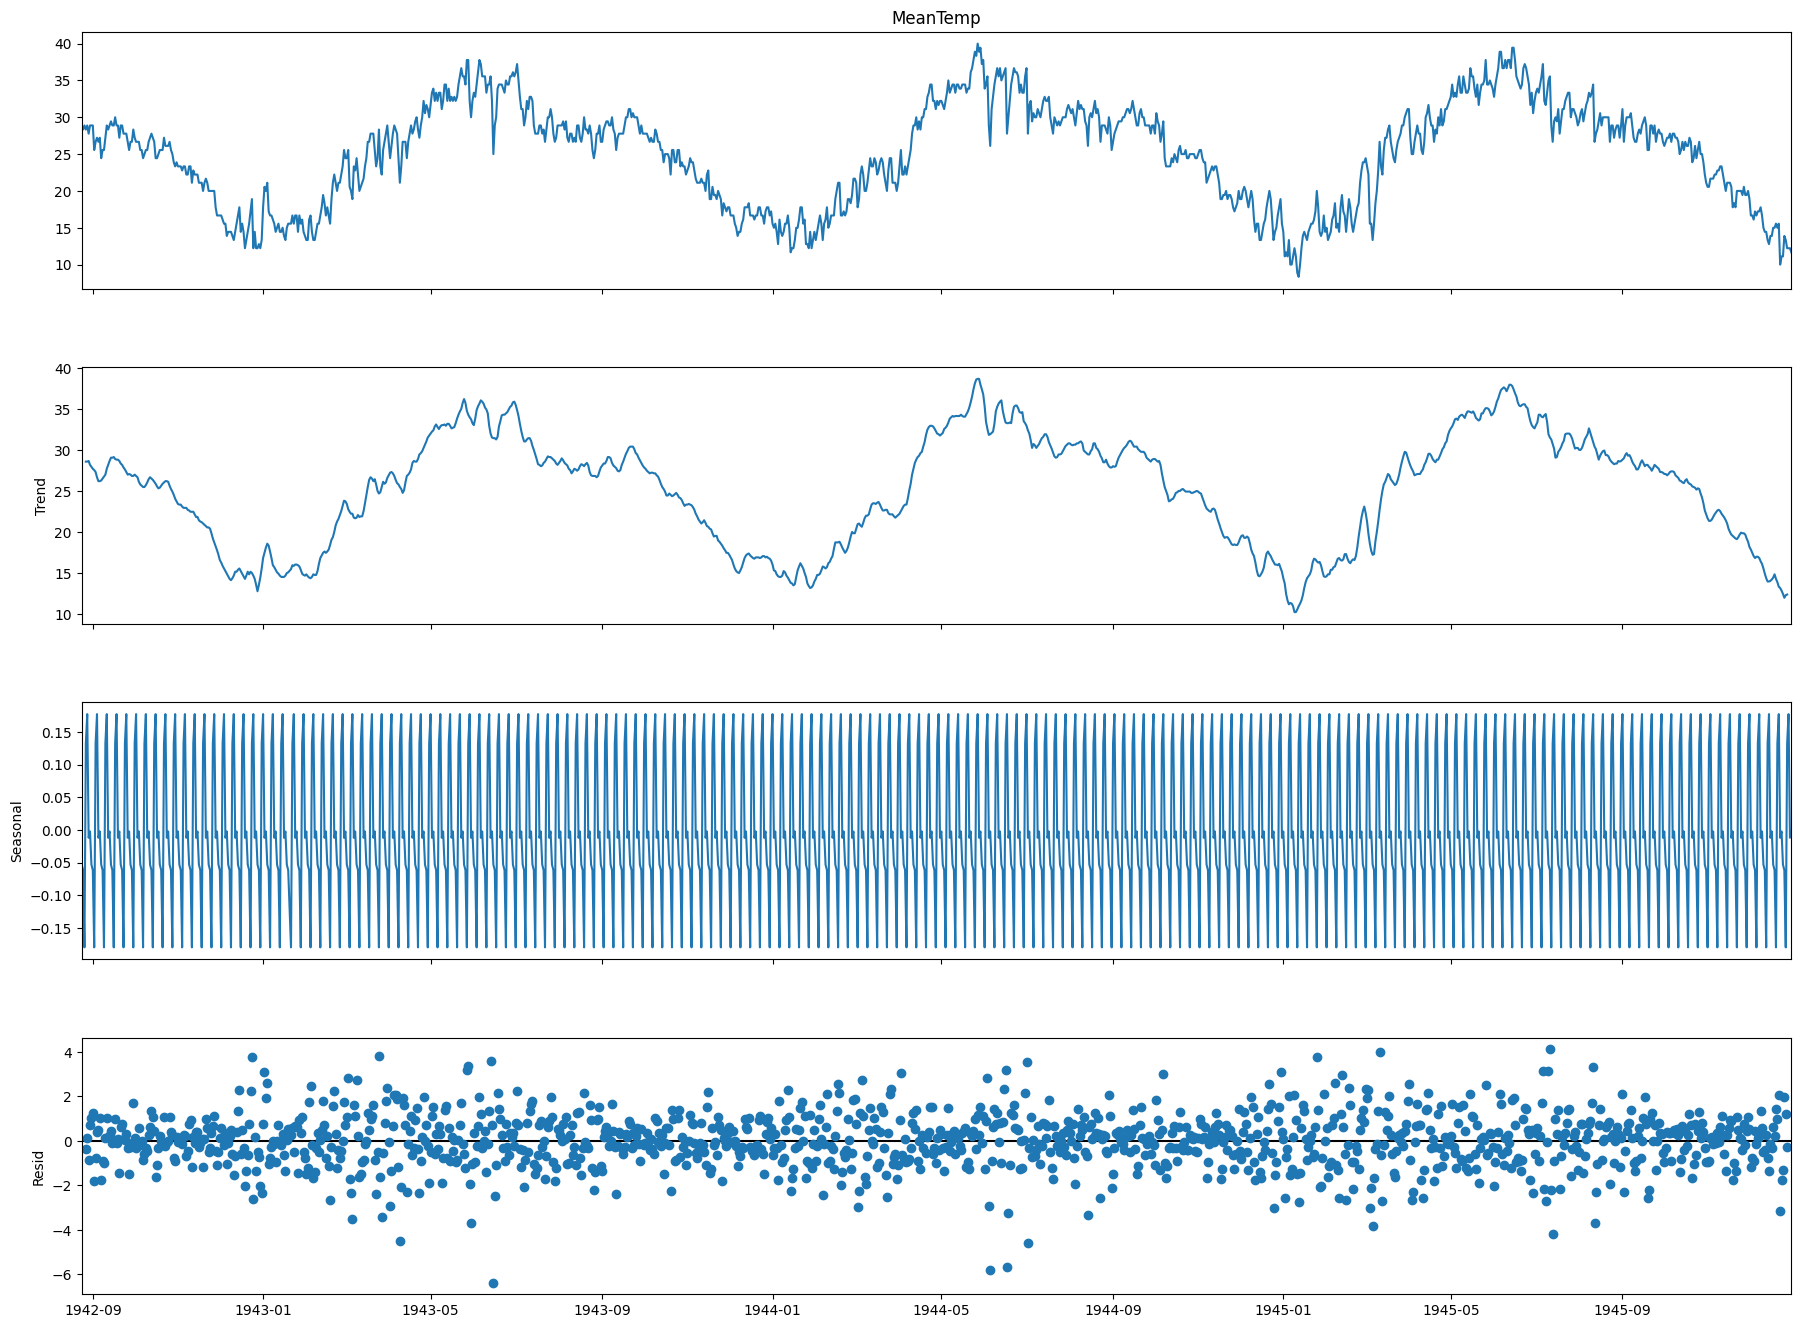

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

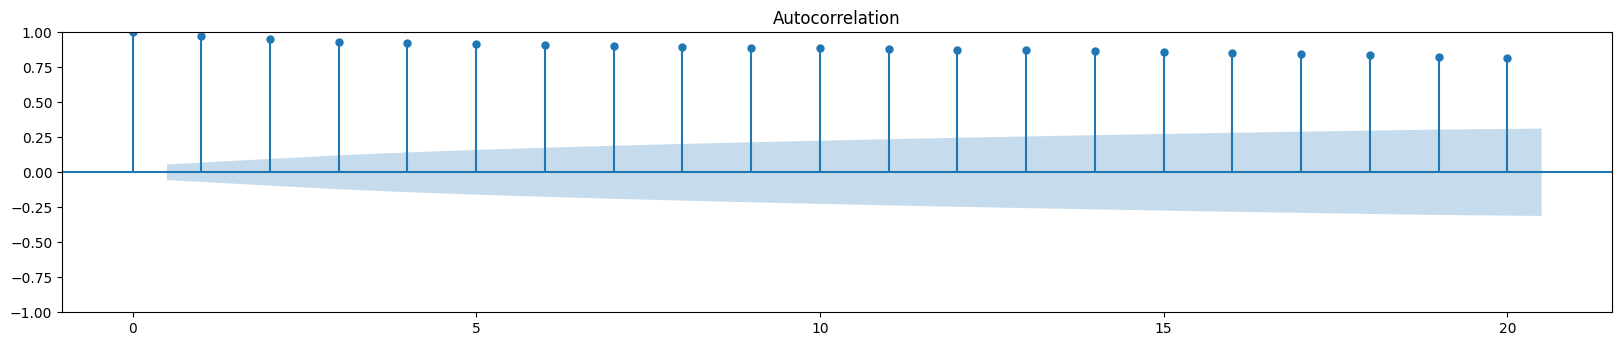

In [13]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [14]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설 혹은 귀무가설이라는 키워드를 사용하여 서술하세요.

A1.ADF 테스트에서 p value가 0.05 이상이므로, 귀무가설을 기각하지 않고, 시계열 데이터가 비정상성을 가진다고 볼 수 있다.

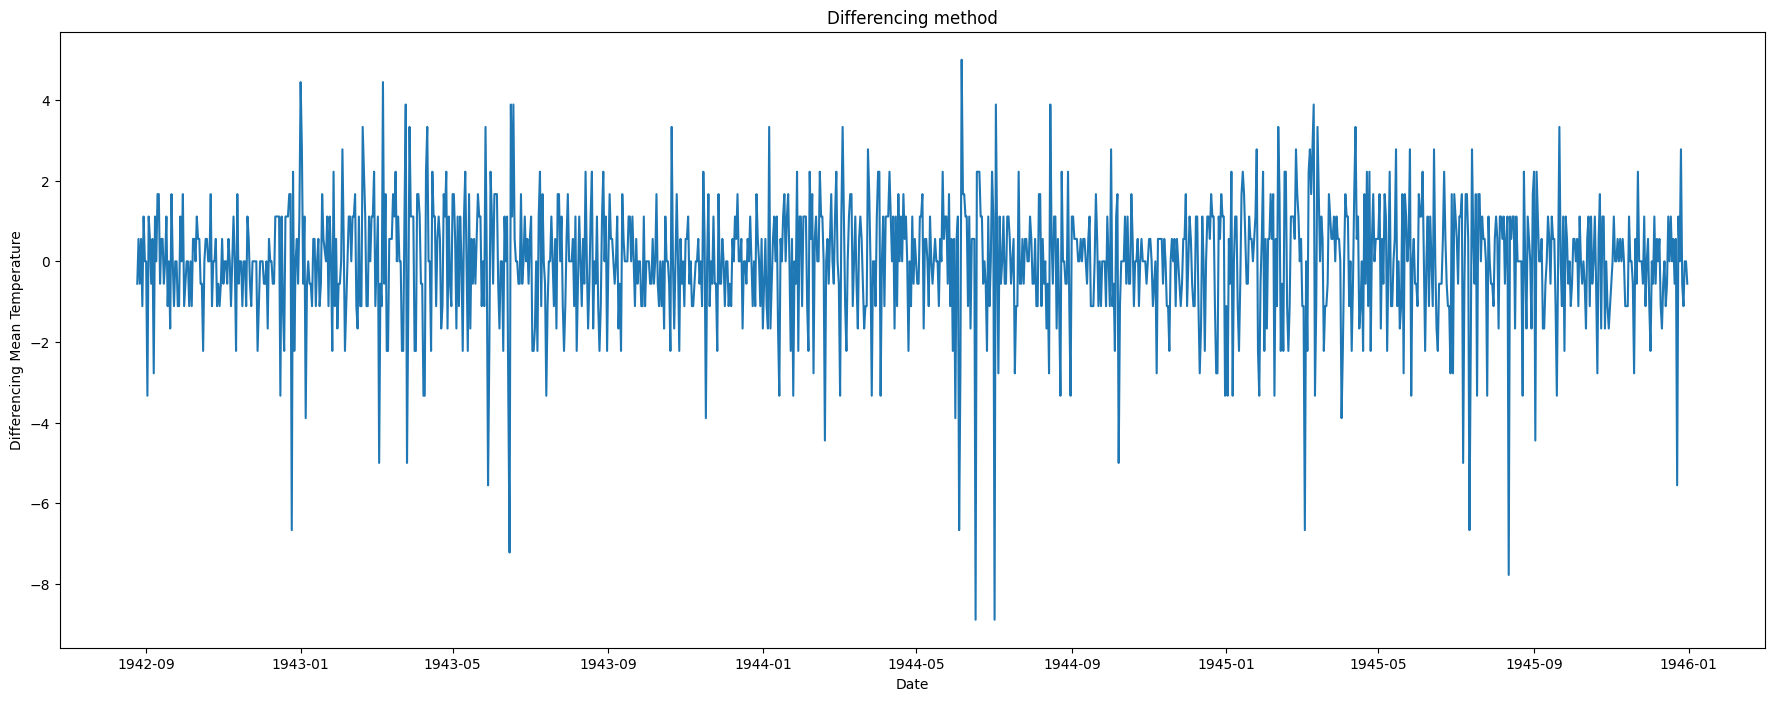

In [15]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [16]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2. 차분에서 p value가 매우 감소한 것을 보아 귀무가설을 기각할 수 있고, 정상성을 가진다고 판단할 수 있다. 차분을 통해 추세가 제거되면서 정상성을 가지게 되었다고 볼 수 있다.

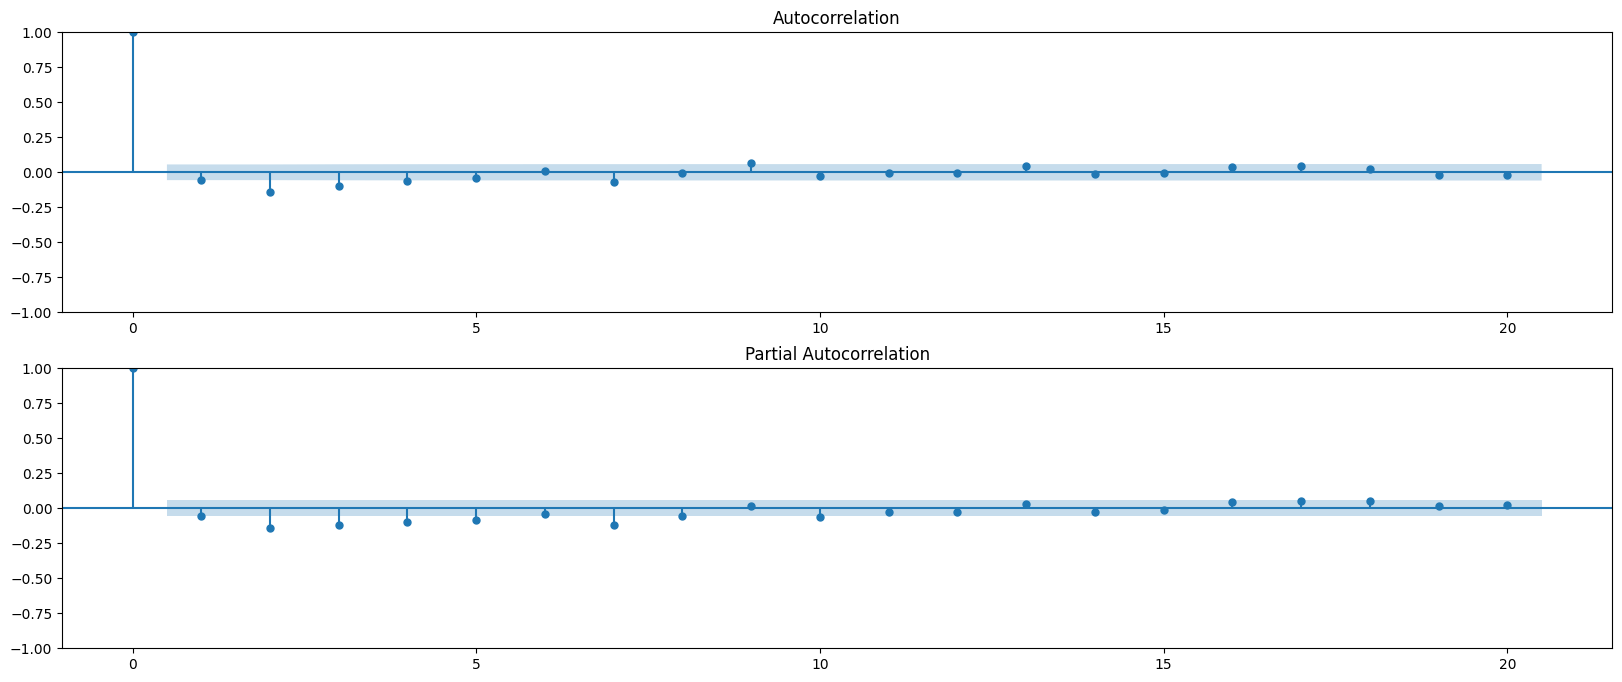

In [17]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3. 위는 시계열 데이터가 이전 시점의 값들과 얼마나 상관관계를 가지는지 보여주며 아래는 특정 값이 이전 영향을 제거한 상태에서 얼마나 직접적인 상관관계를 가지는지를 보여준다. p는 PACF가 1에서 절단되므로 1, q는 ACF에서 패턴이 없으므로 0
p = 1 ,q = 0

### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


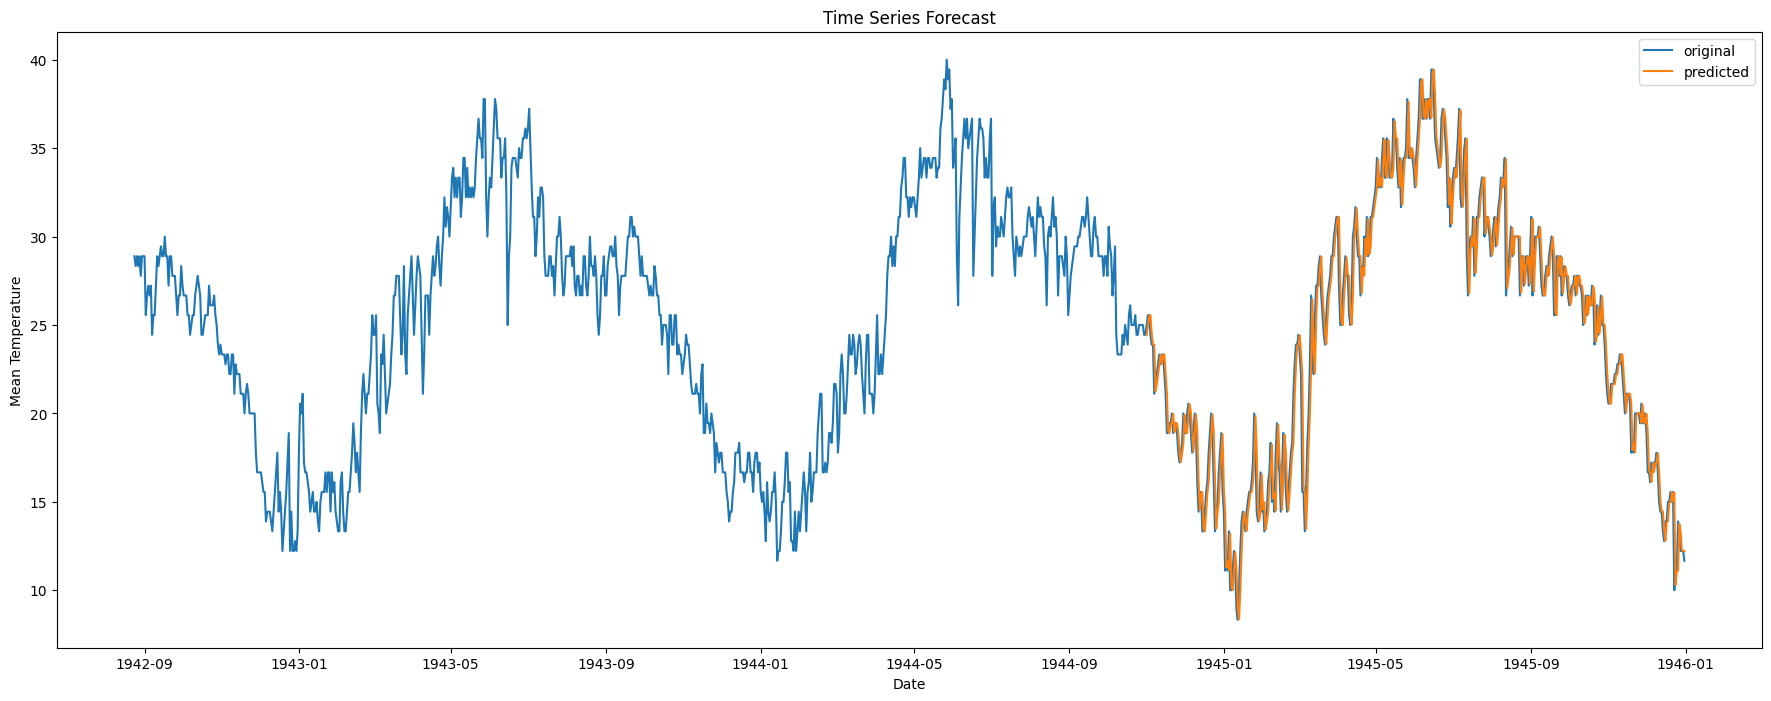

In [18]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p =1
d =1
q =0

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_1065/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


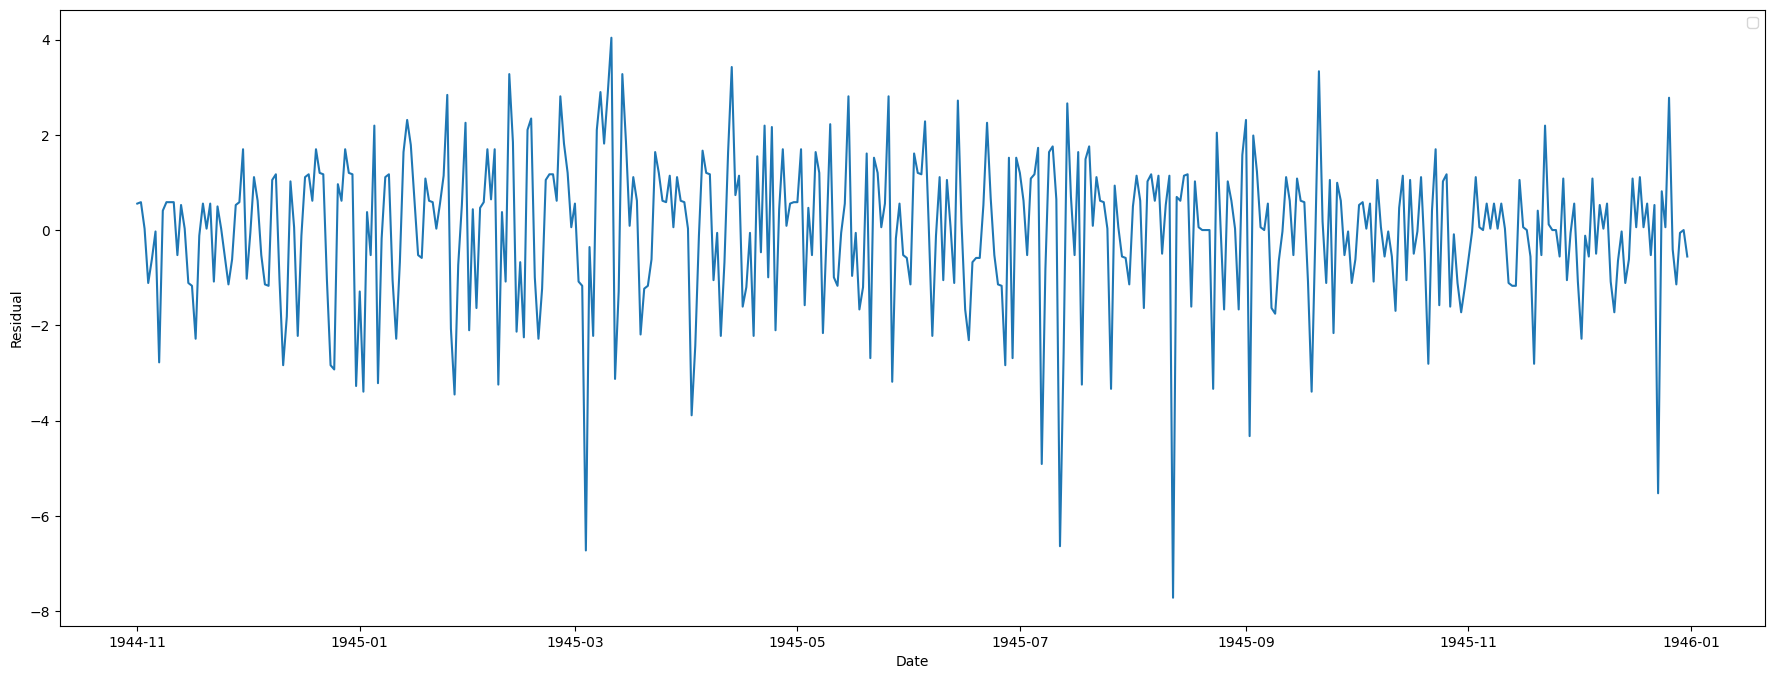

In [19]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

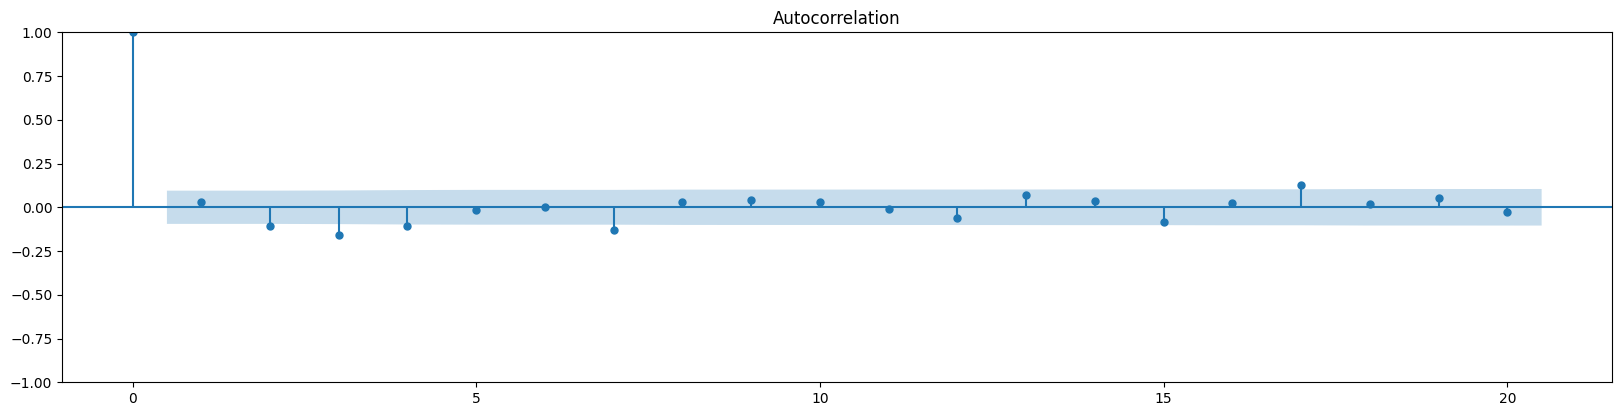

In [20]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [21]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.339884
p-value: 0.000000
Critical Values:
	1%: -3.446
	5%: -2.868
	10%: -2.570


In [22]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [23]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.555,0.978,1.566,5.426


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4. 예측 그래프의 실제값과 예측값이 유사하게 움직이므로 모델이 패턴을 잘 설명하고 있다. 또한 예측 성능이 우수하게 나왔으며, p-value가 작게 나와 귀무가설을 기각하여 정상성 확보된 것을 판단 할 수 있다.

### DLinear
Q4. DLinear 모델은 kernel, learning rate, epoch 등 여러 하이퍼파라미터가 존재합니다. 아래 코드에서 각 하이퍼파라미터를 직접 조정하시며 가장 좋은 결과가 나온 값을 작성해주세요. 또한 그 값이 좋은 결과라고 판단하게 된 근거를 작성해주세요. (ex. 에러율, 시각화 결과 등) 마지막으로, ARIMA와 비교하여 해당 데이터셋에서는 어느 모델이 더 적합한 것 같은지 모델의 이름과 그 이유를 작성해주세요.

A4.
R2	Corr	RMSE	MAPE \
0	89.19	0.953	2.27	7.407

kernal size : 181, LR ; 0.0001, epoch : 60

R2값을 기준으로 성능이 상승하고, epoch를 늘려가면서 loss의 지속적인 감소를 통해 과적합인지 판단하면서 하이퍼파라미터 조정을 진행,
데이터의 단순성 때문에 ARIMA 모델에서 전체적인 성능이 좋게 나왔기 때문에 ARIMA 모델이 더 적합하다고 판단한다.

In [24]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
data = ts.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [26]:
seq_len = 365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [27]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=11):
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [28]:
model = DLinear(seq_len, pred_len).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 60

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.009231
Epoch 20, Loss: 0.006095
Epoch 30, Loss: 0.005127
Epoch 40, Loss: 0.004612
Epoch 50, Loss: 0.004283
Epoch 60, Loss: 0.003987


In [29]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)

while len(predictions) < total_test_len:

  x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

  with torch.no_grad():
    pred = model(x).cpu().numpy().flatten()

  # 남은 길이보다 많이 예측했으면 자르기
  remaining = total_test_len - len(predictions)
  pred = pred[:remaining]

  predictions.extend(pred)

  # window 업데이트 (예측값 붙이고 앞에서 제거)
  current_window = np.concatenate(
    [current_window[pred_len:], pred.reshape(-1,1)],
    axis=0
  )

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

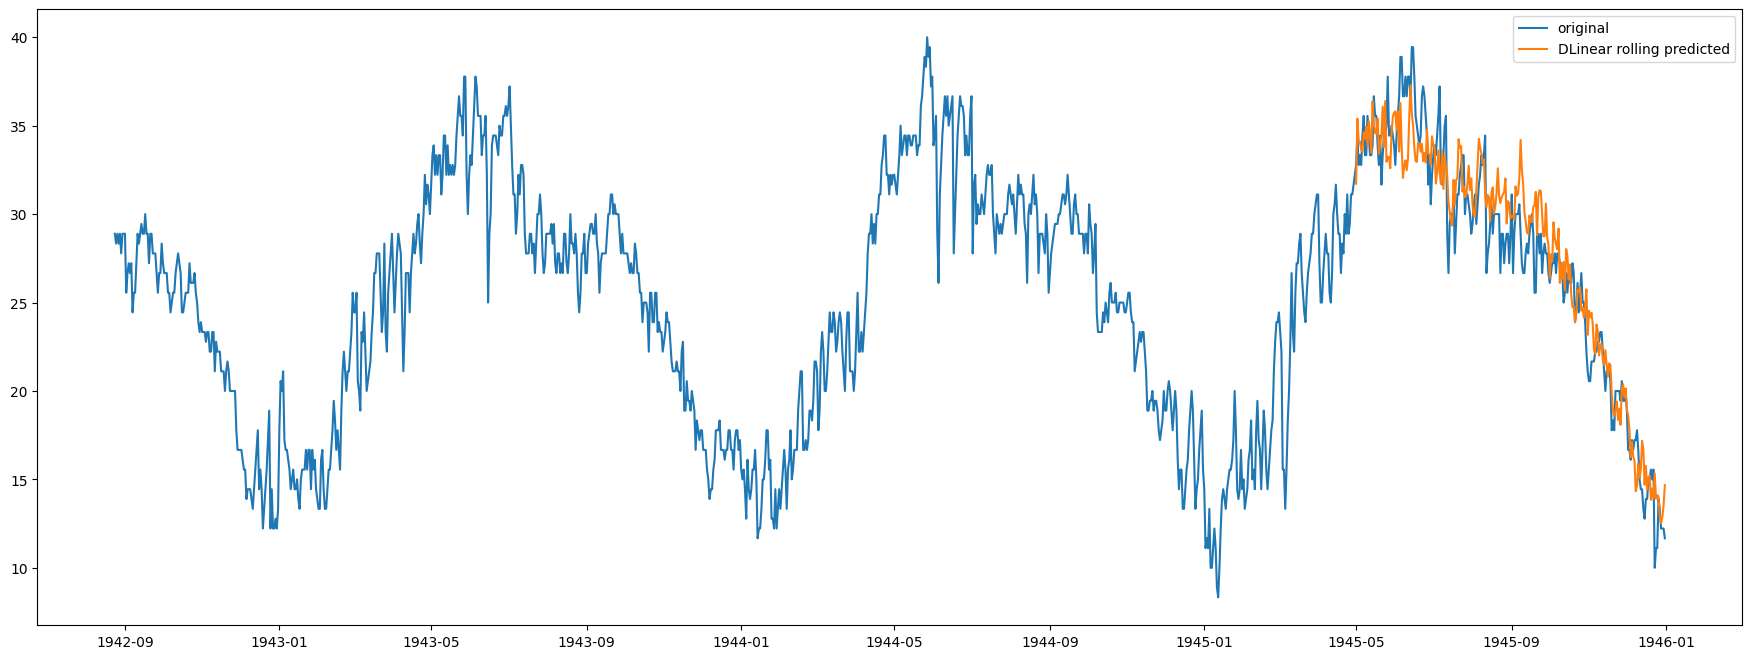

In [30]:
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values, label="original")

test_dates = ts.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [31]:
test_start_idx = train_size

y_true = ts.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(245,) (245,)


,R2,Corr,RMSE,MAPE
0,90.514,0.954,2.126,6.38


## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [32]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

,0
NAME,
ACCRA,1157
AGRA,1225
ATAR,876
BALBOA/ALBROOK,2185
BAMRAULI,868
BANGALORE,1180
BERMUDA,1487
CAMAGUEY,1055
CAPE PALMAS,935


In [44]:
loc_sta_accra = loc_df[loc_df["NAME"] == "ACCRA"].WBAN
weather_bin_accra = weather_df[weather_df.STA == int(loc_sta_accra)].copy()
weather_bin_accra["Date"] = pd.to_datetime(weather_bin_accra["Date"])

timeSeries_accra = weather_bin_accra.loc[:, ["Date", "Precip"]]
timeSeries_accra.index = timeSeries_accra.Date
ts_accra = timeSeries_accra.drop("Date", axis=1)

/tmp/ipykernel_1065/3854427968.py:2: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin_accra = weather_df[weather_df.STA == int(loc_sta_accra)].copy()


In [45]:
timeSeries_accra = weather_bin_accra.loc[:, ["Date", "Precip"]]
timeSeries_accra.index = timeSeries_accra.Date
ts_accra = timeSeries_accra.drop("Date", axis=1)

# 강수량에는 결측치가 있을 수 있으므로 처리
ts_accra = ts_accra.dropna()
weather_bin_accra = weather_bin_accra.dropna(subset=["Precip"])

print(f"ACCRA 데이터 기간: {ts_accra.index.min()} ~ {ts_accra.index.max()}")
print(f"총 데이터 수: {len(ts_accra)}")
ts_accra.head()

ACCRA 데이터 기간: 1942-07-01 00:00:00 ~ 1945-08-31 00:00:00
총 데이터 수: 1157


,Precip
Date,
1942-07-01,1.016
1942-07-02,0.000
1942-07-03,2.540
1942-07-04,2.540
1942-07-05,0.000


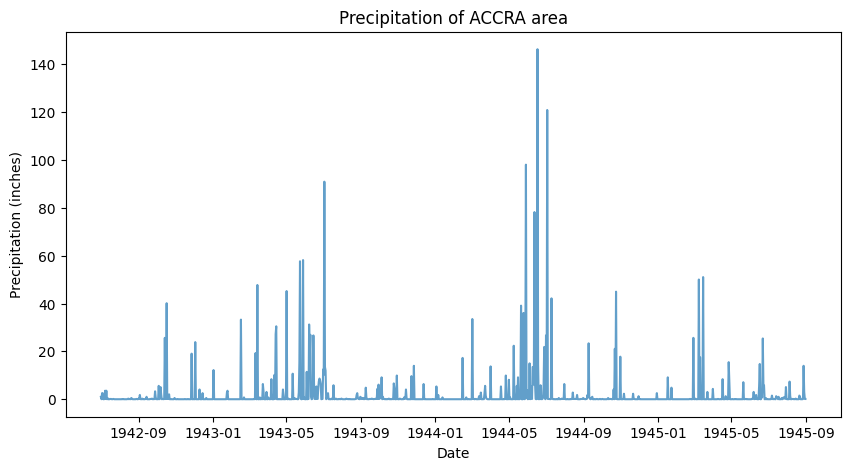

In [48]:
import matplotlib.pyplot as plt

# ACCRA 지역의 평균 강수량 시계열 그래
plt.figure(figsize=(10, 5))
plt.plot(weather_bin_accra.Date, weather_bin_accra.Precip, alpha=0.7)
plt.title("Precipitation of ACCRA area")
plt.xlabel("Date")
plt.ylabel("Precipitation (inches)")
plt.show()

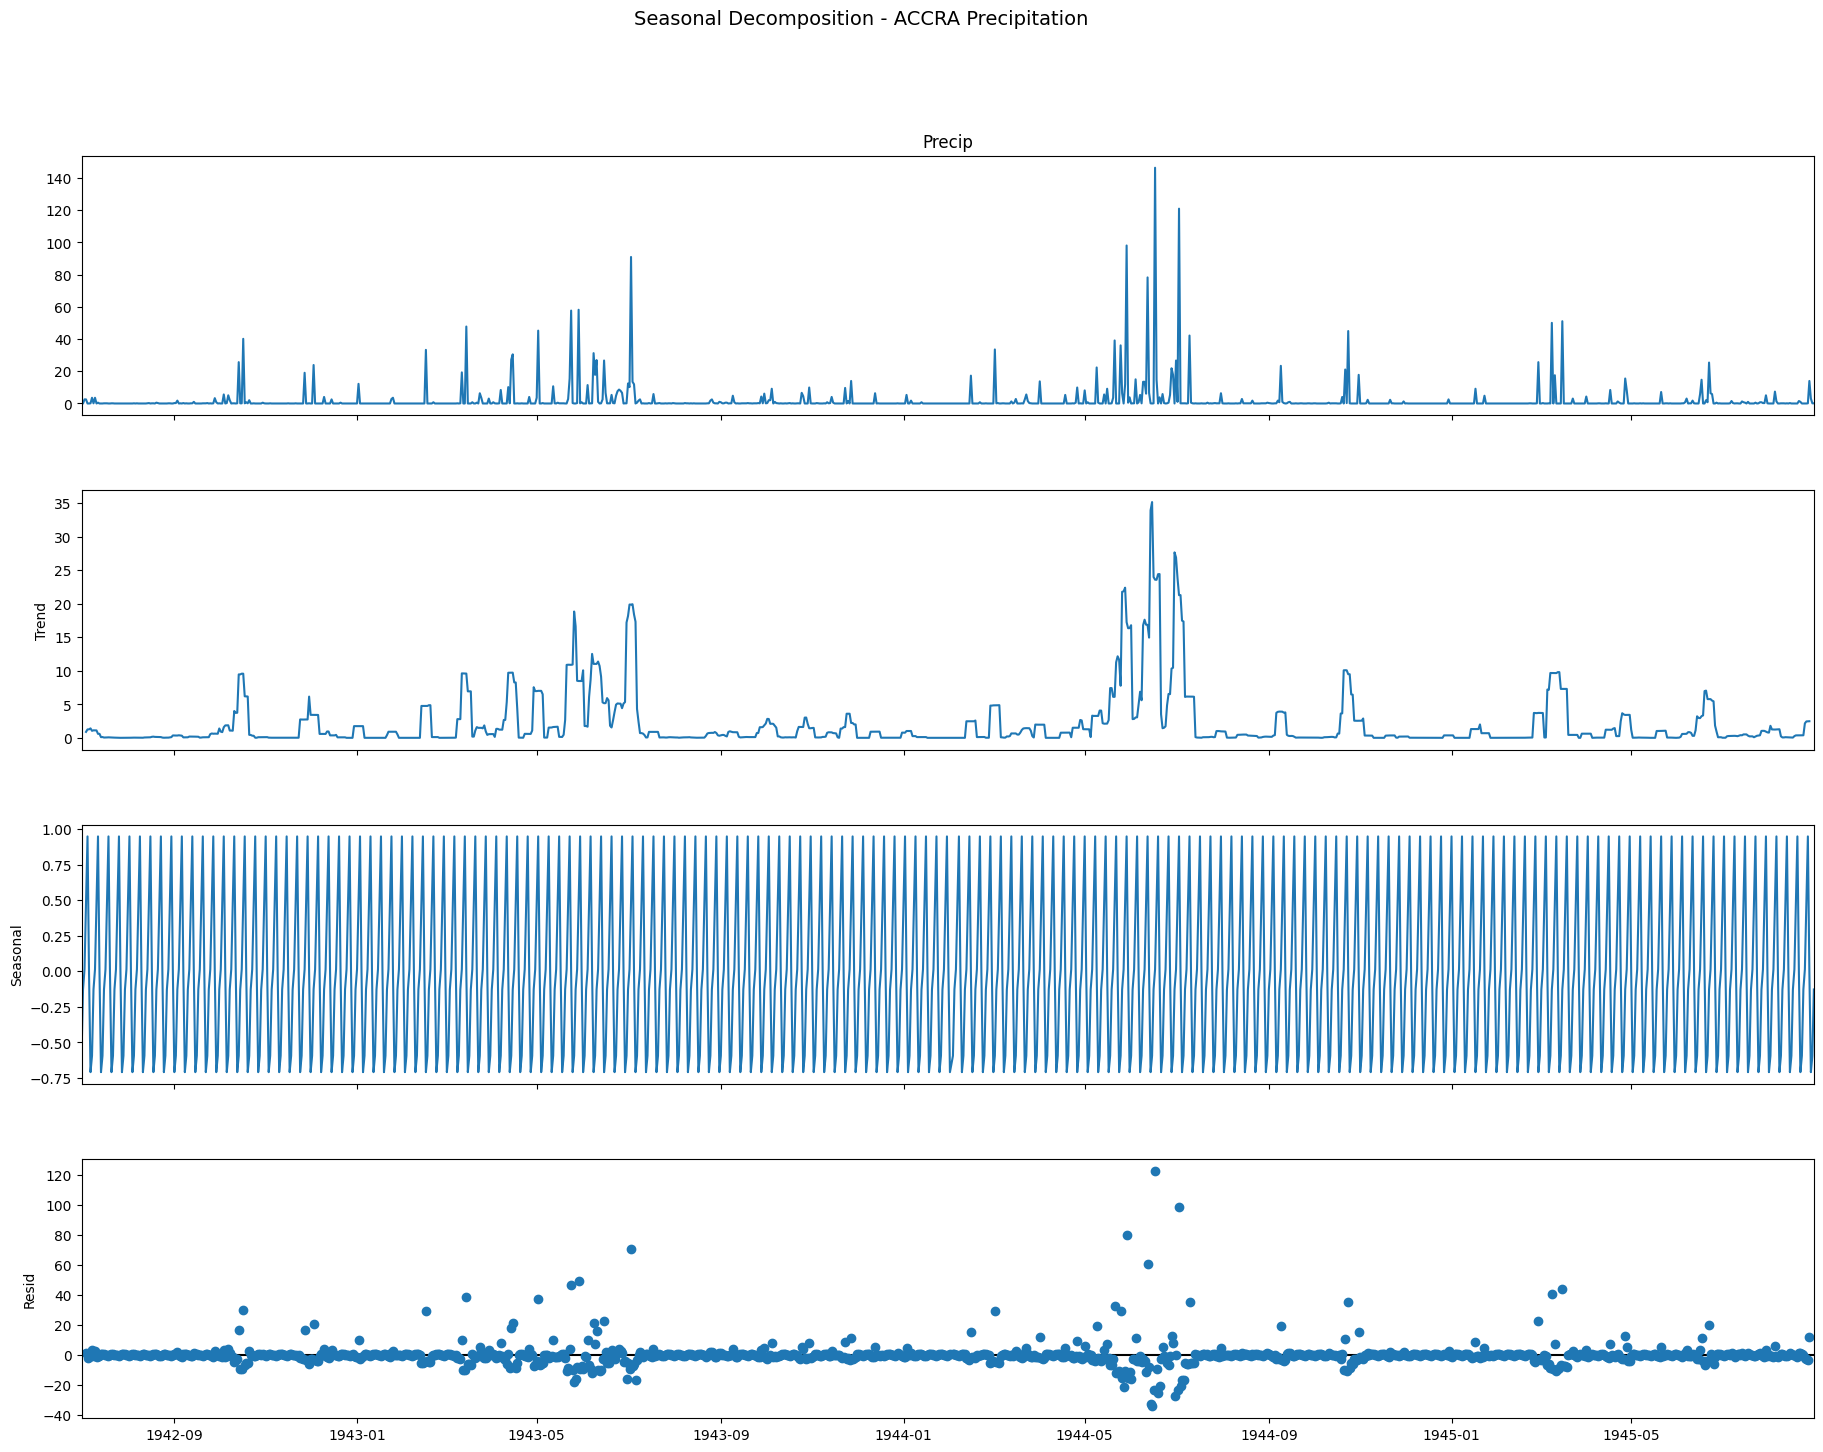

In [49]:
from statsmodels.tsa.seasonal import seasonal_decompose


result_accra = seasonal_decompose(ts_accra["Precip"], model='additive', period=7)
fig_accra = result_accra.plot()
fig_accra.set_size_inches(20, 15)
plt.suptitle("Seasonal Decomposition - ACCRA Precipitation", y=1.02, fontsize=14)
plt.show()

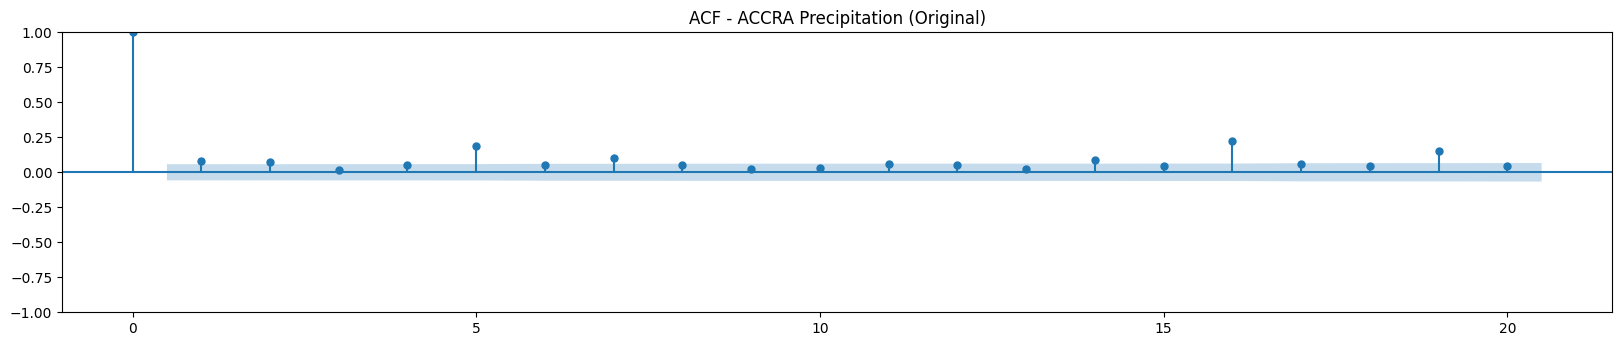

In [50]:
import statsmodels.api as sm

# ACCRA 지역의 평균 강수량 시계열 데이터에 대한 ACF
fig_acf = plt.figure(figsize=(20, 8))
ax1 = fig_acf.add_subplot(211)
fig_acf = sm.graphics.tsa.plot_acf(ts_accra, lags=20, ax=ax1)
plt.title("ACF - ACCRA Precipitation (Original)")
plt.show()

In [51]:
from statsmodels.tsa.stattools import adfuller
# ACCRA 지역의 평균 기온 시계열 데이터(ts_accra)에 대해 ADF 테스트
result_adf = adfuller(ts_accra["Precip"])
print("=== ADF Test (원본 강수량) ===")
print(f"ADF Statistic: {result_adf[0]:.6f}")
print(f"p-value: {result_adf[1]:.6f}")
for key, value in result_adf[4].items():
    print(f"\t{key}: {value:.3f}")

=== ADF Test (원본 강수량) ===
ADF Statistic: -3.746492
p-value: 0.003505
	1%: -3.436
	5%: -2.864
	10%: -2.568


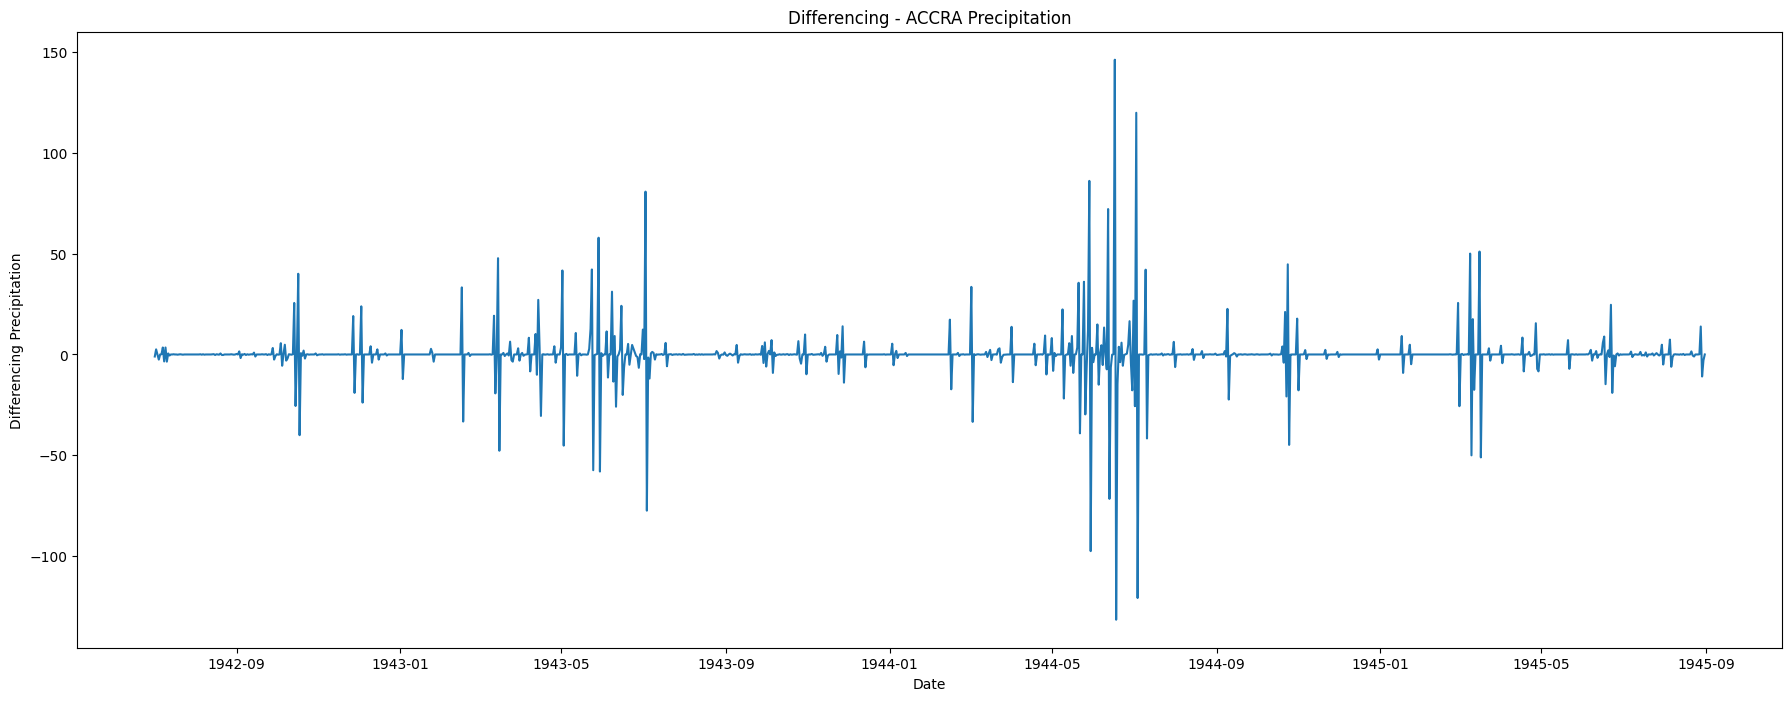

=== ADF Test (1차 차분 후) ===
ADF Statistic: -12.020696
p-value: 0.000000
	1%: -3.436
	5%: -2.864
	10%: -2.568


In [52]:
# ACCRA 지역의 평균 기온 시계열 데이터의 비정상성을 제거하기 위해 1차 차분(differencing)
ts_accra_diff = ts_accra - ts_accra.shift()

plt.figure(figsize=(22, 8))
plt.plot(ts_accra_diff)
plt.title("Differencing - ACCRA Precipitation")
plt.xlabel("Date")
plt.ylabel("Differencing Precipitation")
plt.show()

In [53]:
from statsmodels.tsa.stattools import adfuller
result_adf_diff = adfuller(ts_accra_diff["Precip"].dropna())
print("=== ADF Test (1차 차분 후) ===")
print(f"ADF Statistic: {result_adf_diff[0]:.6f}")
print(f"p-value: {result_adf_diff[1]:.6f}")
for key, value in result_adf_diff[4].items():
    print(f"\t{key}: {value:.3f}")

=== ADF Test (1차 차분 후) ===
ADF Statistic: -12.020696
p-value: 0.000000
	1%: -3.436
	5%: -2.864
	10%: -2.568


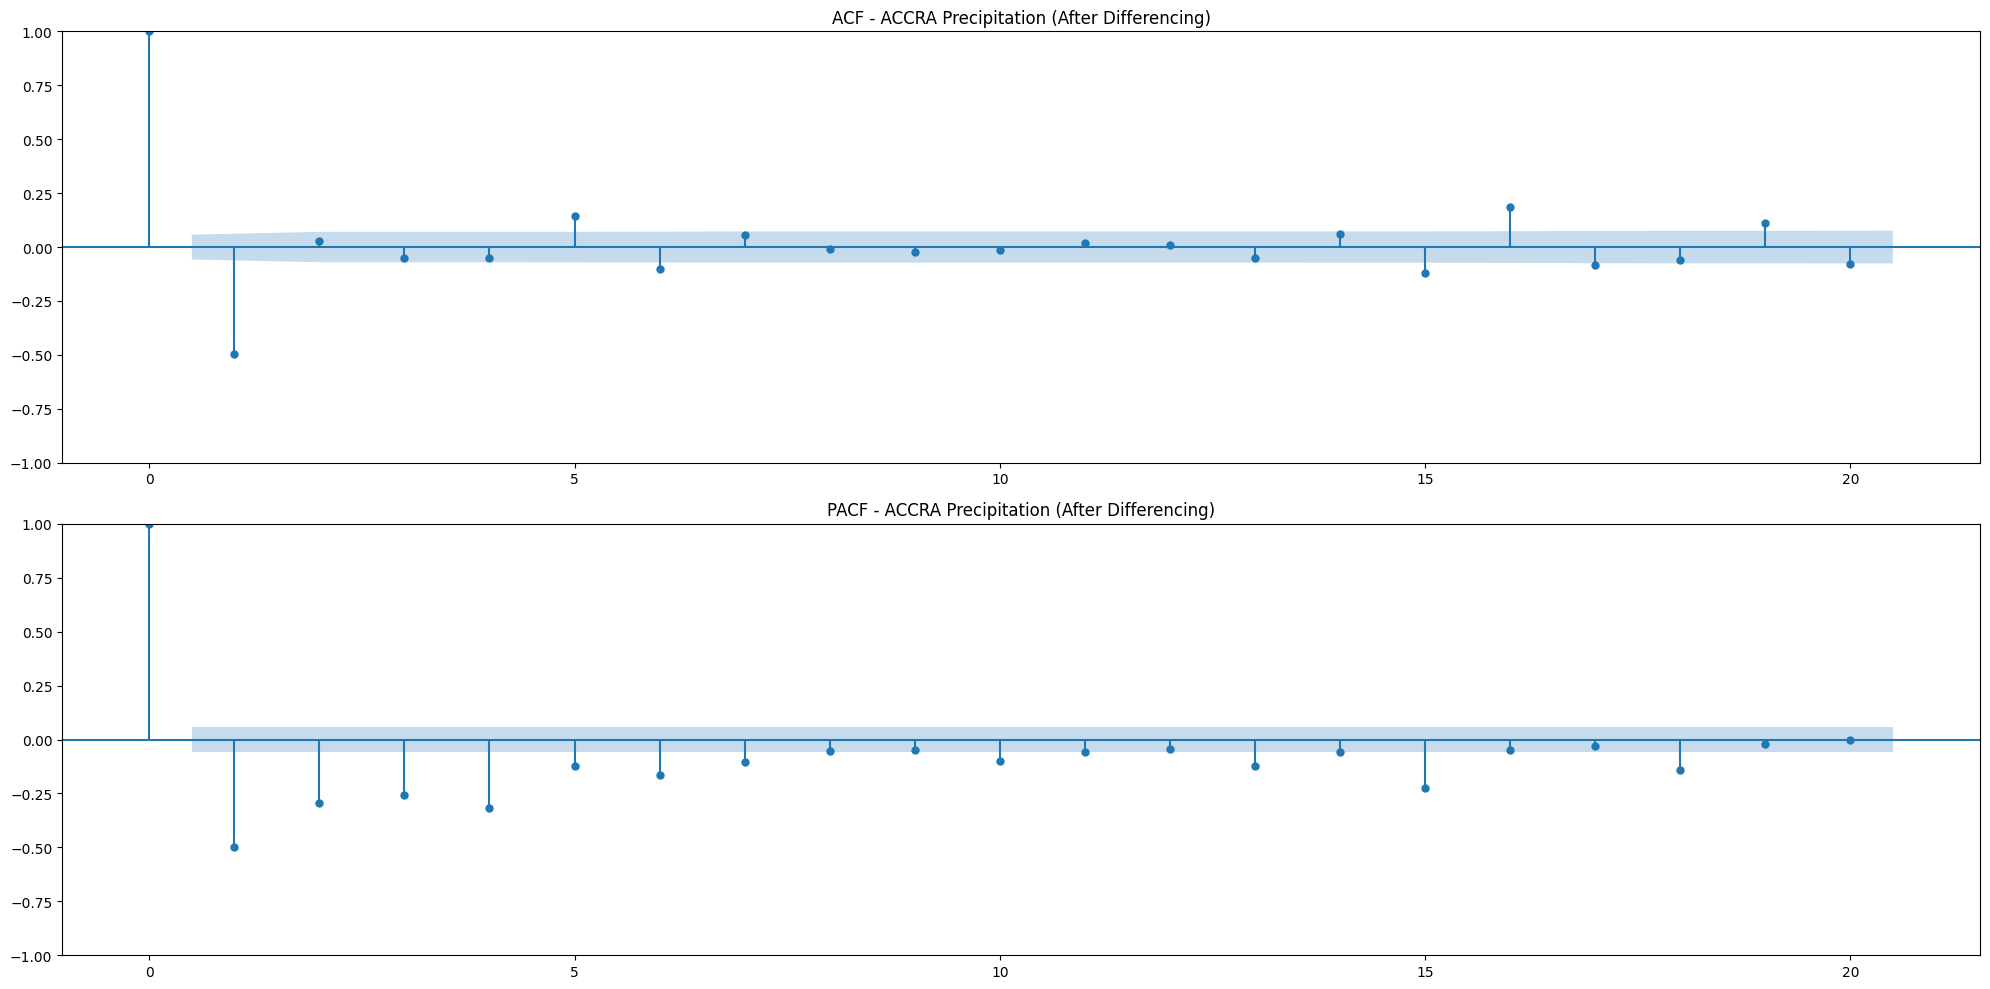

In [54]:
import statsmodels.api as sm

ts_diff_clean = ts_accra_diff.dropna()

fig_diff = plt.figure(figsize=(20, 10))
ax1 = fig_diff.add_subplot(211)
sm.graphics.tsa.plot_acf(ts_diff_clean, lags=20, ax=ax1)
ax1.set_title("ACF - ACCRA Precipitation (After Differencing)")

ax2 = fig_diff.add_subplot(212)
sm.graphics.tsa.plot_pacf(ts_diff_clean, lags=20, ax=ax2)
ax2.set_title("PACF - ACCRA Precipitation (After Differencing)")
plt.tight_layout()
plt.show()


In [64]:
p_accra = 1
d_accra = 0
q_accra = 0

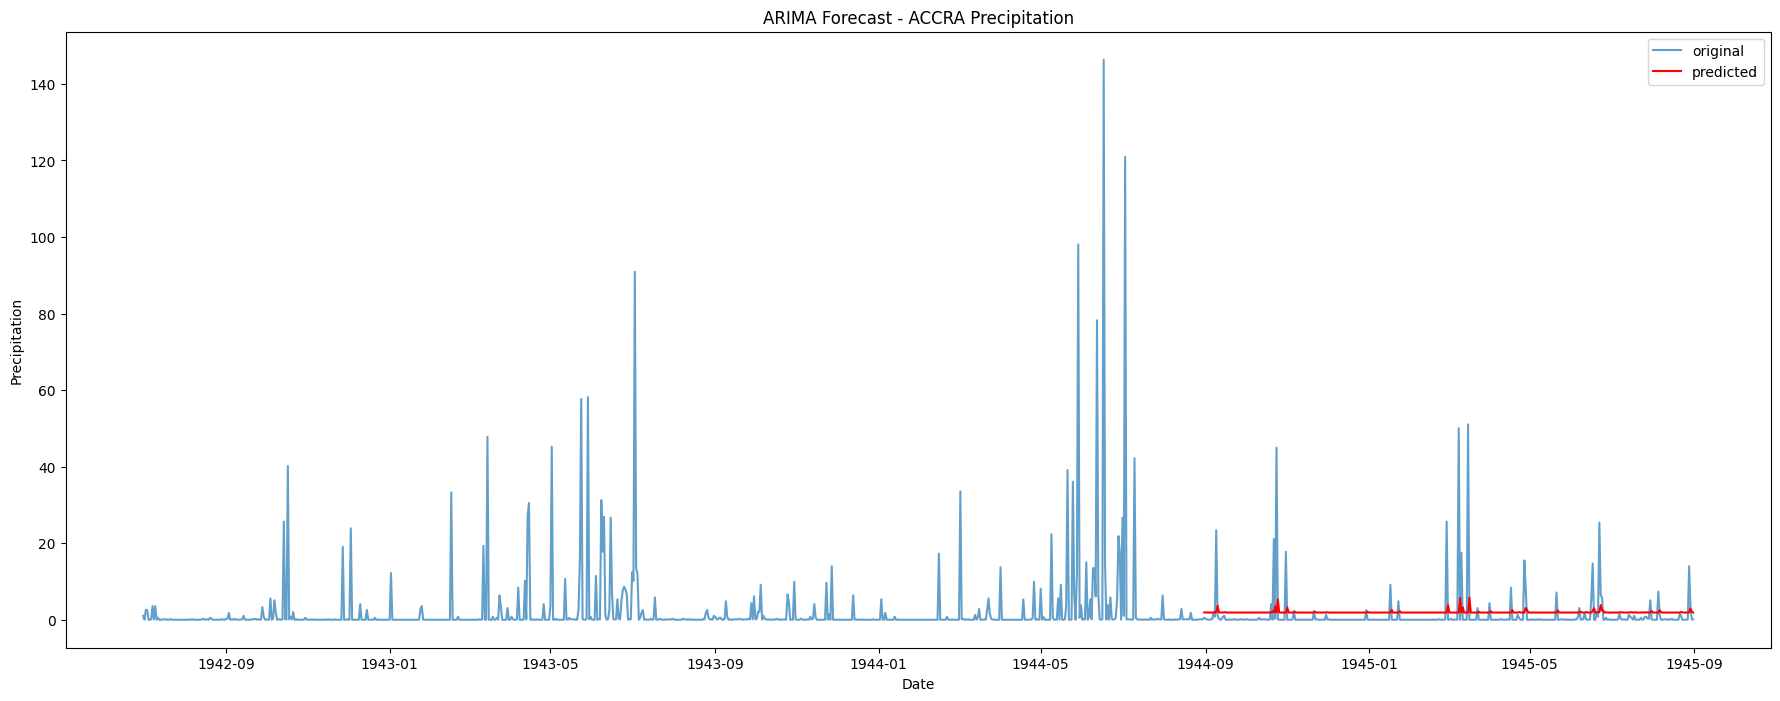

In [70]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime


# 마지막 1년 데이터를 예측 구간으로 설정
start_index_accra = ts_accra.index.max() - pd.DateOffset(years=1)
end_index_accra = ts_accra.index.max()
forecast_accra = model_fit_accra.predict(
    start=start_index_accra, end=end_index_accra, typ='levels'
)

# 시각화
plt.figure(figsize=(22, 8))
plt.plot(weather_bin_accra.Date, weather_bin_accra.Precip, label="original", alpha=0.7)
plt.plot(forecast_accra.index, forecast_accra, label="predicted", color='red')
plt.title("ARIMA Forecast - ACCRA Precipitation")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.legend()
plt.show()

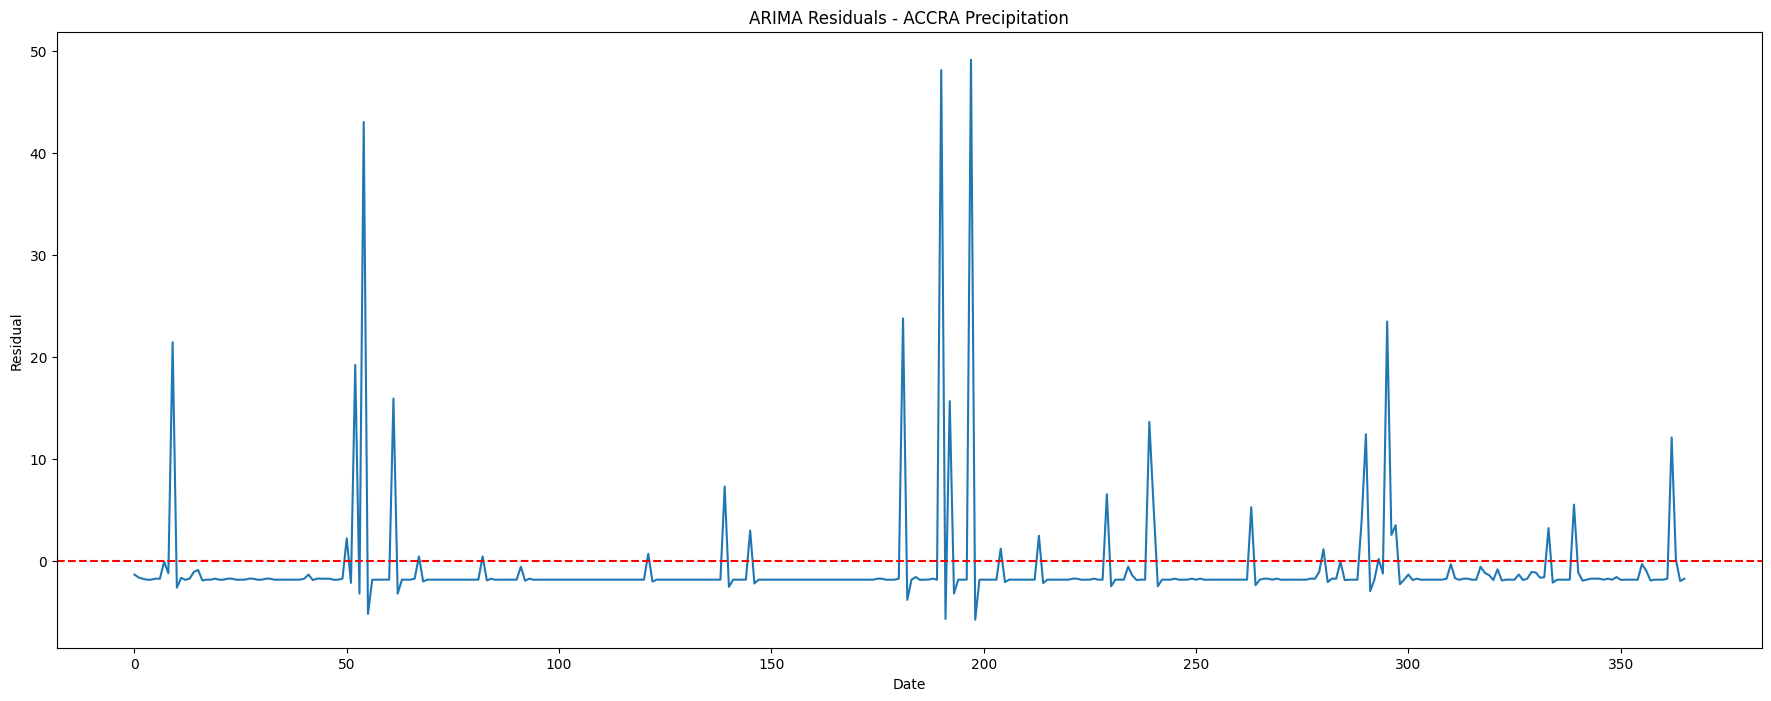

In [71]:
actual_accra = weather_bin_accra[weather_bin_accra.Date >= start_index_accra]["Precip"]
forecast_array = np.array(forecast_accra)
actual_array = np.array(actual_accra)

# 길이 맞추기
min_len = min(len(actual_array), len(forecast_array))
actual_array = actual_array[:min_len]
forecast_array = forecast_array[:min_len]
resi_accra = actual_array - forecast_array

plt.figure(figsize=(22, 8))
plt.plot(resi_accra)
plt.title("ARIMA Residuals - ACCRA Precipitation")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.axhline(0, color='red', linestyle='--')
plt.show()

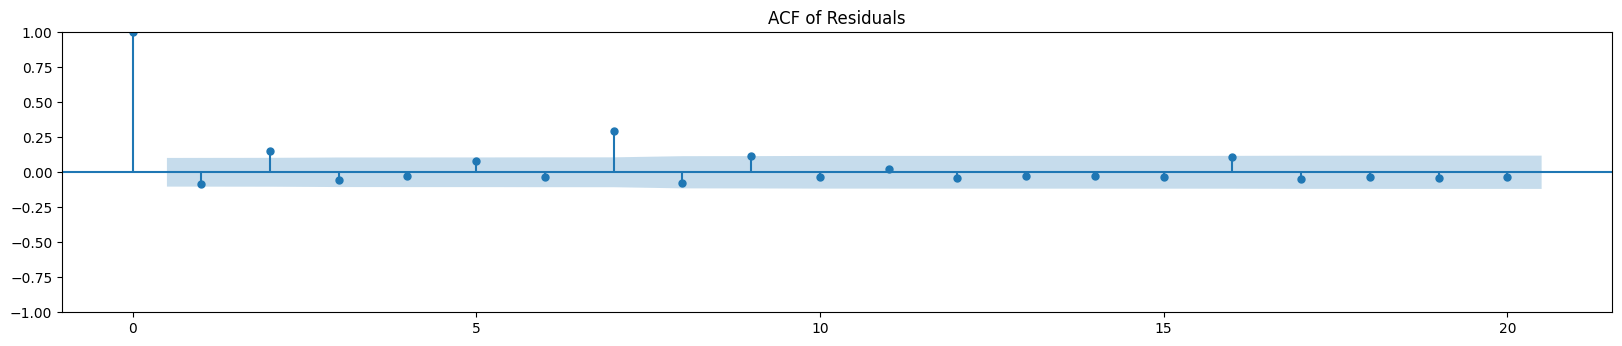

In [67]:
fig_resi = plt.figure(figsize=(20, 8))
ax_resi = fig_resi.add_subplot(211)
sm.graphics.tsa.plot_acf(resi_accra, lags=20, ax=ax_resi)
ax_resi.set_title("ACF of Residuals")
plt.show()

In [68]:
result_adf_resi = adfuller(resi_accra)
print("=== 잔차 ADF Test ===")
print(f"ADF Statistic: {result_adf_resi[0]:.6f}")
print(f"p-value: {result_adf_resi[1]:.6f}")

=== 잔차 ADF Test ===
ADF Statistic: -5.109492
p-value: 0.000013


In [69]:
def scoring(y_true, y_pred):
    r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
    corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
    mape = round(metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3)
    rmse = round(np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3)
    df = pd.DataFrame({"R2": r2, "Corr": corr, "RMSE": rmse, "MAPE": mape}, index=[0])
    return df

arima_score = scoring(actual_array, forecast_array)
print("=== ARIMA 성능 지표 (ACCRA Precip) ===")
print(arima_score)

=== ARIMA 성능 지표 (ACCRA Precip) ===
      R2   Corr   RMSE          MAPE
0 -2.453  0.002  5.486  5.978324e+17


In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_accra = ts_accra.values
train_size_accra = int(len(data_accra) * 0.8)
train_data_accra = data_accra[:train_size_accra]
test_data_accra = data_accra[train_size_accra:]

scaler_accra = MinMaxScaler()
train_scaled_accra = scaler_accra.fit_transform(train_data_accra)
test_scaled_accra = scaler_accra.transform(test_data_accra)

seq_len = 365
pred_len = 30

Epoch 10/80, Loss: 0.003531
Epoch 20/80, Loss: 0.002816
Epoch 30/80, Loss: 0.002459
Epoch 40/80, Loss: 0.002222
Epoch 50/80, Loss: 0.002072
Epoch 60/80, Loss: 0.002055
Epoch 70/80, Loss: 0.001921
Epoch 80/80, Loss: 0.001872


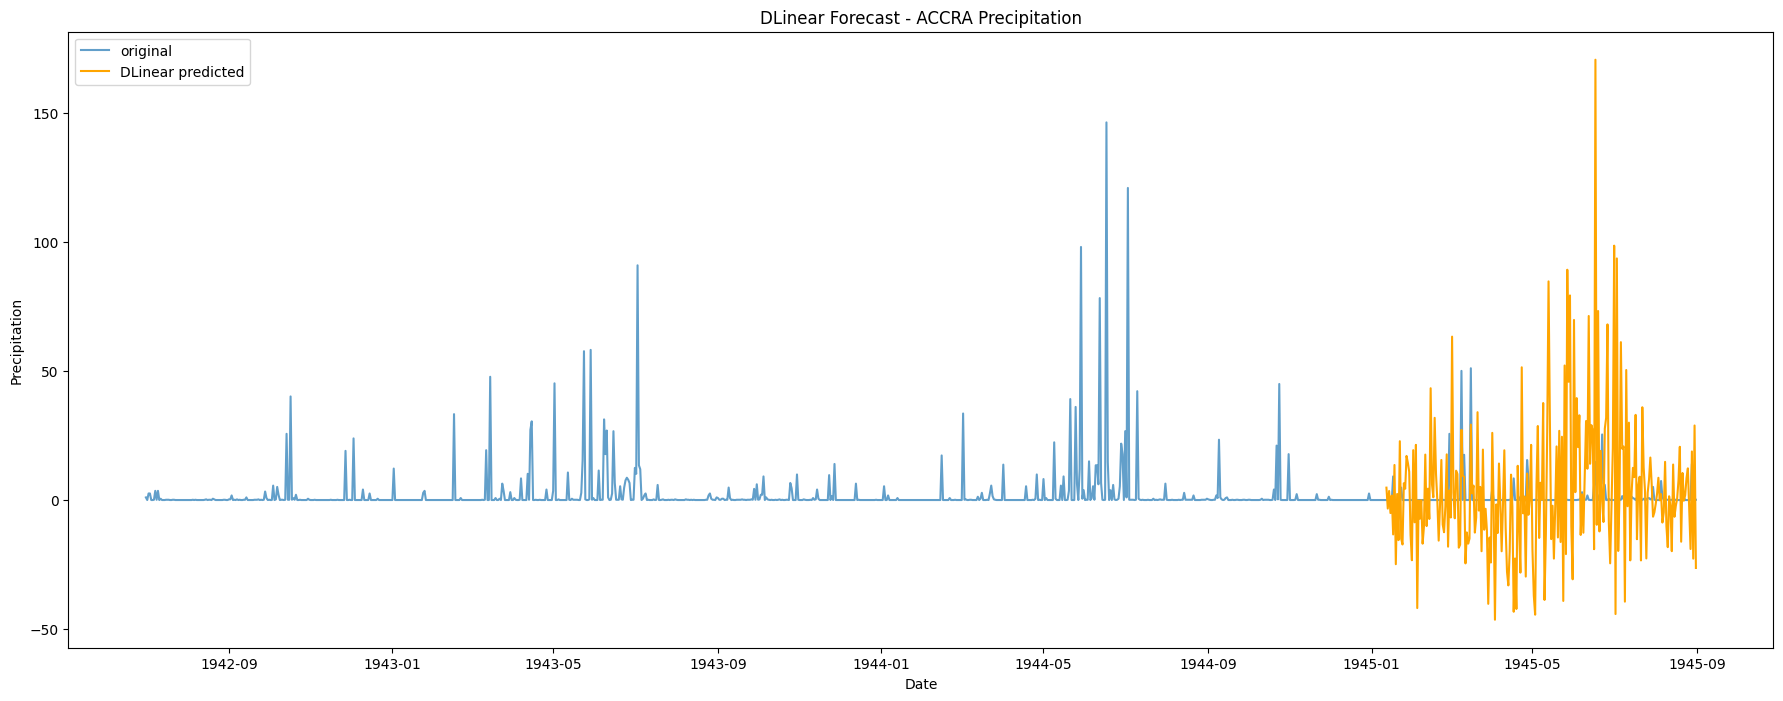

=== DLinear 성능 지표 (ACCRA Precip) ===
         R2   Corr    RMSE          MAPE
0 -2288.195  0.121  27.771  5.547045e+18


In [73]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

class DLinear(nn.Module):
    def __init__(self, seq_len, pred_len, kernel_size=25):
        super().__init__()
        self.moving_avg = nn.AvgPool1d(
            kernel_size=kernel_size, stride=1, padding=kernel_size//2
        )
        self.linear_seasonal = nn.Linear(seq_len, pred_len)
        self.linear_trend = nn.Linear(seq_len, pred_len)

    def series_decomp(self, x):
        x = x.permute(0, 2, 1)
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend

    def forward(self, x):
        seasonal, trend = self.series_decomp(x)
        seasonal = seasonal.squeeze(1)
        trend = trend.squeeze(1)
        return self.linear_seasonal(seasonal) + self.linear_trend(trend)

train_dataset_accra = TimeSeriesDataset(train_scaled_accra, seq_len, pred_len)
train_loader_accra = DataLoader(train_dataset_accra, batch_size=16, shuffle=True)

model_dl_accra = DLinear(seq_len, pred_len, kernel_size=25).to(device)
criterion_accra = nn.MSELoss()
optimizer_accra = torch.optim.Adam(model_dl_accra.parameters(), lr=0.001)
epochs_accra = 80

for epoch in range(epochs_accra):
    model_dl_accra.train()
    total_loss = 0
    for x, y in train_loader_accra:
        x, y = x.to(device), y.to(device)
        optimizer_accra.zero_grad()
        output = model_dl_accra(x)
        loss = criterion_accra(output, y.squeeze(-1))
        loss.backward()
        optimizer_accra.step()
        total_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs_accra}, Loss: {total_loss/len(train_loader_accra):.6f}")

# 예측
model_dl_accra.eval()
predictions_accra = []
current_window = train_scaled_accra[-seq_len:].copy()
total_test_len = len(test_scaled_accra)

while len(predictions_accra) < total_test_len:
    x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model_dl_accra(x).cpu().numpy().flatten()
    remaining = total_test_len - len(predictions_accra)
    pred = pred[:remaining]
    predictions_accra.extend(pred)
    current_window = np.concatenate(
        [current_window[pred_len:], pred.reshape(-1, 1)], axis=0
    )

forecast_dl_accra = scaler_accra.inverse_transform(
    np.array(predictions_accra).reshape(-1, 1)
)

plt.figure(figsize=(22, 8))
plt.plot(ts_accra.index, ts_accra.values, label="original", alpha=0.7)
test_dates_accra = ts_accra.index[train_size_accra:]
plt.plot(test_dates_accra, forecast_dl_accra.flatten(), label="DLinear predicted", color='orange')
plt.title("DLinear Forecast - ACCRA Precipitation")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.legend()
plt.show()

y_true_dl = ts_accra.values[train_size_accra:].reshape(-1)
y_pred_dl = forecast_dl_accra.reshape(-1)
dl_score = scoring(y_true_dl, y_pred_dl)
print("=== DLinear 성능 지표 (ACCRA Precip) ===")
print(dl_score)

**추가실습 분석 결과**\
**분석 설정**

실습 1: AGRA 지역 / MeanTemp(평균 기온)\
추가실습: ACCRA 지역 / Precip(강수량)


ACCRA 강수량은 원본 데이터의 p-value가 0.0035로 이미 귀무가설을 기각하여 차분 없이 정상성을 만족(d=0) 했다. 이는 기온처럼 추세가 있어서 정상성이 깨지는 것이 아니라, 강수량은 애초에 뚜렷한 추세가 없는 데이터이다.


ARIMA 모델은 실습 1의 기온 예측이 우수했던 것과 대조적으로, 강수량에서는 ARIMA가 의미 있는 예측을 하지 못했다.

DLinear는
R2 = -2238, RMSE = 27.771, Corr = 0.121로 예측값이 음수까지 발산하며 완전히 실패하였다. 이는 강수량 데이터는 분해 가능한 규칙적 추세·계절 구조가 없어 모델의 기본 가정이 위반되었기 때문이다.


**핵심 인사이트**\

모델의 가정과 데이터 특성의 일치가 성능을 결정한다\
ARIMA와 DLinear 모두 데이터가 어느 정도 정규분포에 가깝고 선형적인 패턴을 가진다고 가정합니다. 기온은 이 가정을 만족하여 두 모델 모두 합리적으로 작동했으나, 강수량은 극단적 비정규분포로 두 모델 모두 실패하였다.\
대부분의 날이 0이고 간헐적으로 극단값이 튀는 강수량 데이터에는 ARIMA, DLinear 모델이 적합하지 않다.